# CSE 2600 HW 1

## Q1

A. The mean of the data is 29.37, and the median is 25.0.
B. The mode of the data set is 33 and it occures 4 times. Data is unimodal.
C. The Q1 is 20.5, Q2 is 25.0, and Q3 is 35.0.
D. The five-number summary is: Min = 3, Q1 = 20.5, Q2 = 25.0, Q3 = 35.0, Max = 70.


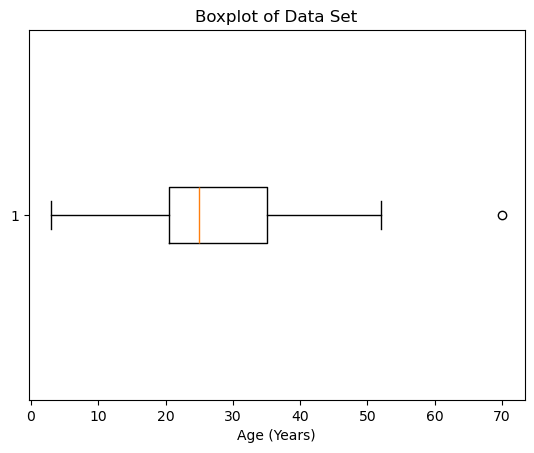

In [47]:
import numpy as np 
from collections import Counter
import matplotlib.pyplot as plt

#my data set
data = np.array([3, 15, 16, 16, 19, 20, 20, 21, 22, 22, 23, 25, 25, 25, 30, 33, 33, 33, 33, 35, 35, 36, 40, 45, 46, 52, 70])

#Part A, calculate the mean and median of the data. 
rounded_mean = np.round(np.mean(data), decimals=2)
median_value = np.median(data)
print (f"A. The mean of the data is {rounded_mean}, and the median is {median_value}.")

#Part B, calculate the mode of the data.
count = Counter(data)
max_number = __builtins__.max(count.values())
modes = []
for i, index in count.items():
    if index == max_number:
        modes.append(int(i))

if len(modes) == 1:
    print(f"B. The mode of the data set is {modes[0]} and it occures {max_number} times. Data is unimodal.")
elif len(modes) == 2:
    print(f"B. The mode of the data set is {modes[0]} and it occures {max_number} times. Data is bimodal.")
else:
    print(f"B. The mode of the data set is {modes[0]} and it occures {max_number} times. Data is multimodal.")

#Part C, calculate the Q1, Q2, Q3 of the data.
q1 = np.percentile(data, 25)
q2 = median_value
q3 = np.percentile(data, 75)
print(f"C. The Q1 is {q1}, Q2 is {q2}, and Q3 is {q3}.")

#Part D, calculate the five-number summary of the data.
min_val = np.min(data)
max_val = np.max(data)
print(f"D. The five-number summary is: Min = {min_val}, Q1 = {q1}, Q2 = {q2}, Q3 = {q3}, Max = {max_val}.")

#Part E, produce a boxplot of the data.
plt.boxplot(data, vert=False)
plt.title("Boxplot of Data Set")
plt.xlabel("Age (Years)")
plt.show() 

## Q2

A. The data set has 322 rows and 20 columns.
B. The data is from the years: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 23, 24. 
   HmRun records the number of home runs a player hit in that particular year, 
   while CHmRun records the total number of home runs the player has hit in their entire career up to that point.
C. The median values for each numeric variable are: 
AtBat       379.5
Hits         96.0
HmRun         8.0
Runs         48.0
RBI          44.0
Walks        35.0
Years         6.0
CAtBat     1928.0
CHits       508.0
CHmRun       37.5
CRuns       247.0
CRBI        220.5
CWalks      170.5
PutOuts     212.0
Assists      39.5
Errors        6.0
Salary      425.0
dtype: float64


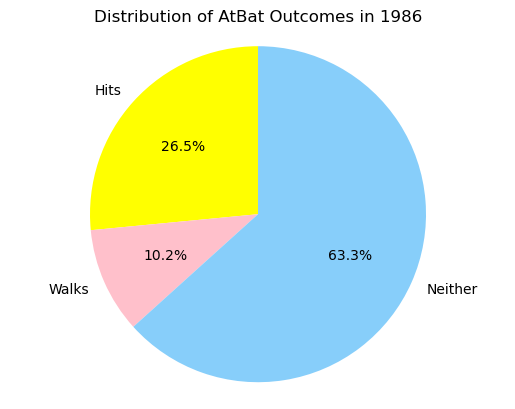

E. There are 59 players missing salary information out of 322.
   These players generally performed worse: they recorded fewer hits (≈71 vs. 108) 
   and fewer home runs (≈7 vs. 12) than those with salaries. 
   Interestingly, they have slightly more years of experience (≈8 vs. 7), which may suggest they are older players with declining performance.
Comparison of players with vs. without salary information:
  Average Hits: 107.83 (with salary) vs. 70.69 (without salary)
  Average Home Runs: 11.62 (with salary) vs. 6.98 (without salary)
  Average Years: 7.31 (with salary) vs. 8.03 (without salary)


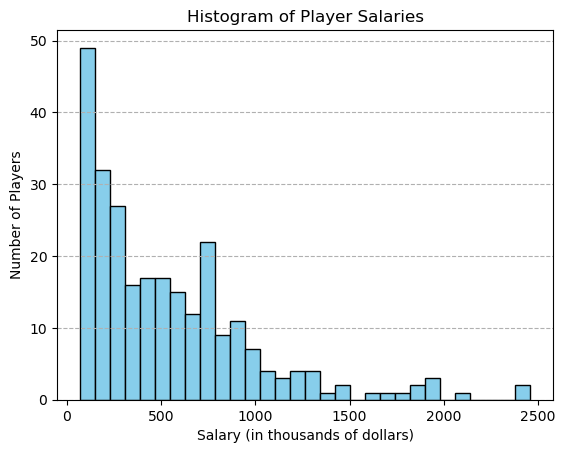

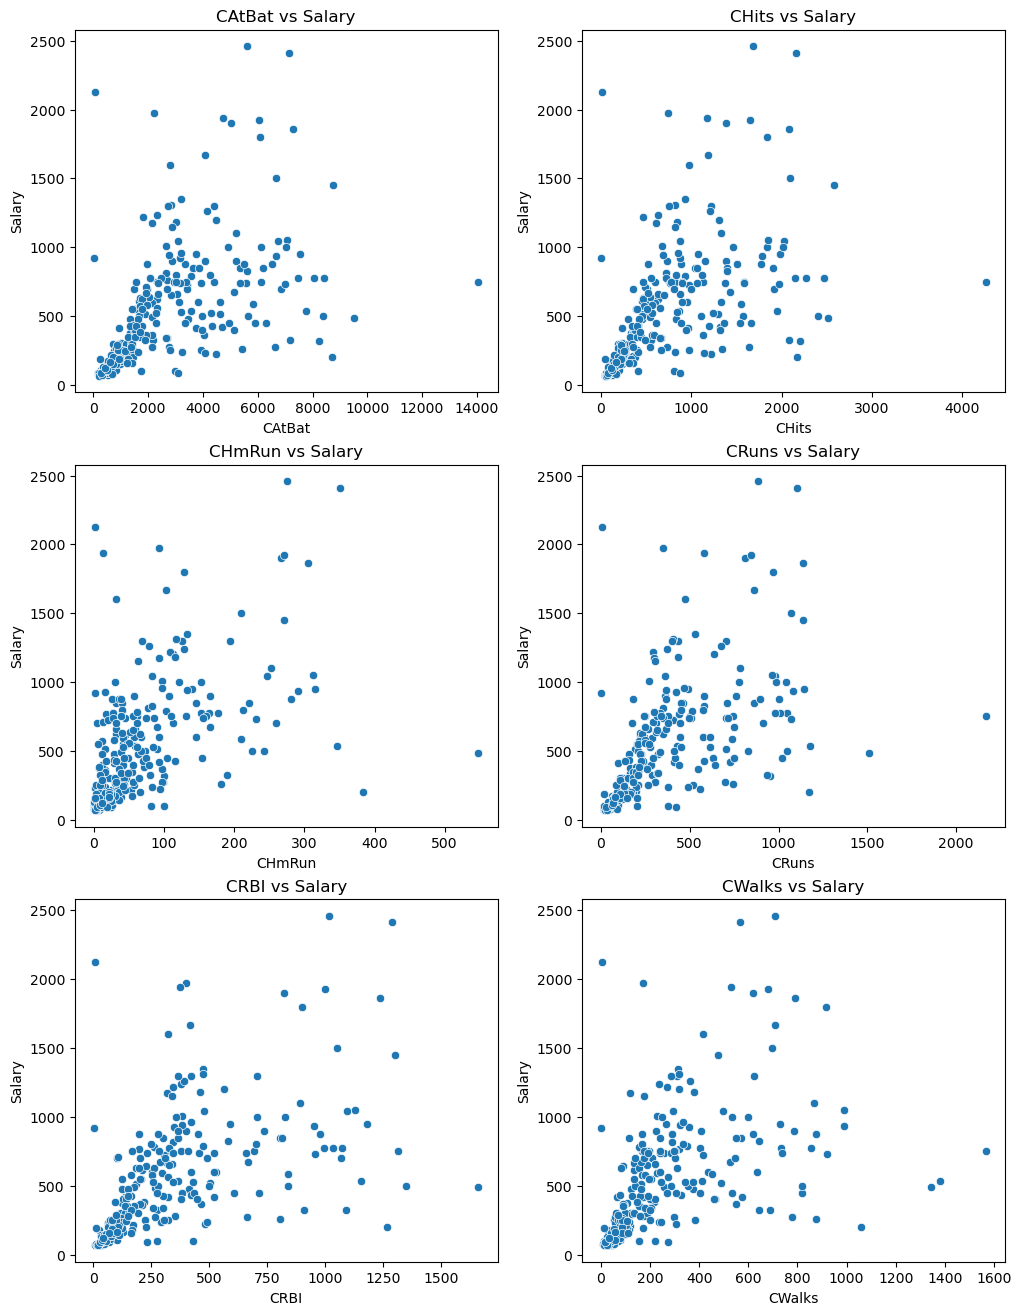

H. Total salary by division:
Division
E    80531.006
W    60417.501
Name: Salary, dtype: float64
The E division spends the most on salaries, totaling $80,531.


In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Setting up the data set 
hitters = pd.read_csv('../data/Hitters.csv')

# Part A, calculate the number of rows and columns in the data set. 
rows, columns = hitters.shape
print(f"A. The data set has {rows} rows and {columns} columns.")

# Part B, From what year(s) is this data? What is the difference between HmRun and CHmRun?
#print(hitters.columns) to see all the column names
#print(hitters[['HmRun', 'CHmRun']].head()) to see the first few rows of these columns of yearly vs career totals
years = sorted(hitters['Years'].unique())
years_str = ', '.join(str(y) for y in years)
print(f"B. The data is from the years: {years_str}. \n   HmRun records the number of home runs a player hit in that particular year, \n   while CHmRun records the total number of home runs the player has hit in their entire career up to that point.")

# Part C, Find the median of each numeric variable.
median_values = hitters.median(numeric_only=True)
print(f"C. The median values for each numeric variable are: \n{median_values}")

# Part D, Produce a pie chart that takes the total of AtBat. 
total_at_bat = hitters['AtBat'].sum()
total_hits = hitters['Hits'].sum()
total_walks = hitters['Walks'].sum()
neither = total_at_bat - (total_hits + total_walks)

labels = ['Hits', 'Walks', 'Neither']
sizes = [total_hits, total_walks, neither]
colors = ['yellow', 'pink', 'lightskyblue']

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.axis('equal')
plt.title('Distribution of AtBat Outcomes in 1986')
plt.show()


# Part E, Salary information

# Count missing salary values
missing_salary = hitters['Salary'].isna().sum()
total_rows = hitters.shape[0]
print(f"E. There are {missing_salary} players missing salary information out of {total_rows}.\n   These players generally performed worse: they recorded fewer hits (≈71 vs. 108) \n   and fewer home runs (≈7 vs. 12) than those with salaries. \n   Interestingly, they have slightly more years of experience (≈8 vs. 7), which may suggest they are older players with declining performance.")


# Split into groups
with_salary = hitters[hitters["Salary"].notna()]
without_salary = hitters[hitters["Salary"].isna()]

# Compare performance
stats = {
    "Average Hits": [with_salary["Hits"].mean(), without_salary["Hits"].mean()],
    "Average Home Runs": [with_salary["HmRun"].mean(), without_salary["HmRun"].mean()],
    "Average Years": [with_salary["Years"].mean(), without_salary["Years"].mean()]
}

print("Comparison of players with vs. without salary information:")
for stat, values in stats.items():
    print(f"  {stat}: {values[0]:.2f} (with salary) vs. {values[1]:.2f} (without salary)")

# Part F, Create a histogram of the Salary variable.
salary_data = hitters["Salary"].dropna()
plt.hist(salary_data, bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of Player Salaries')
plt.xlabel('Salary (in thousands of dollars)')
plt.ylabel('Number of Players')
plt.grid(axis="y", linestyle="--")
plt.show()

# Part G, Pairwise scatterplots for each of the 6 career metrics with Salary
career_cols = ["CAtBat", "CHits", "CHmRun", "CRuns", "CRBI", "CWalks", "Salary"]
career_data = hitters[career_cols].dropna()

# Pairwise scatterplot
fig, axes = plt.subplots(3, 2, figsize=(12, 16))
axes = axes.flatten()

for i, col in enumerate(career_cols[:-1]):
    sns.scatterplot(data=career_data, x=col, y="Salary", ax=axes[i])
    axes[i].set_title(f"{col} vs Salary")
plt.show()

# Part H, Correlation matrix for the career metrics and Salary
# Drop rows with missing Salary first
salary_data = hitters[['Division', 'Salary']].dropna()
total_salary_by_division = salary_data.groupby('Division')['Salary'].sum()
print("H. Total salary by division:")
print(total_salary_by_division)

max_division = total_salary_by_division.idxmax()
max_salary = total_salary_by_division.max()
print(f"The {max_division} division spends the most on salaries, totaling ${max_salary:,.0f}.")
